## IMPORTS AND DATA LOADING

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
df=pd.read_csv('train.csv')

In [4]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [5]:
df.shape

(421570, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [7]:
df.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


## DATA PREPROCESSING AND EDA

In [9]:
df_grouped=df.groupby('Date').agg({'Weekly_Sales':'sum',
                                   'IsHoliday':'max'}).reset_index()

In [10]:
df_grouped['IsHoliday']=df_grouped['IsHoliday'].astype(int)

In [11]:
df_grouped.head()

,Date,Weekly_Sales,IsHoliday
0,2010-02-05,49750740.50,0
1,2010-02-12,48336677.63,1
2,2010-02-19,48276993.78,0
3,2010-02-26,43968571.13,0
4,2010-03-05,46871470.30,0


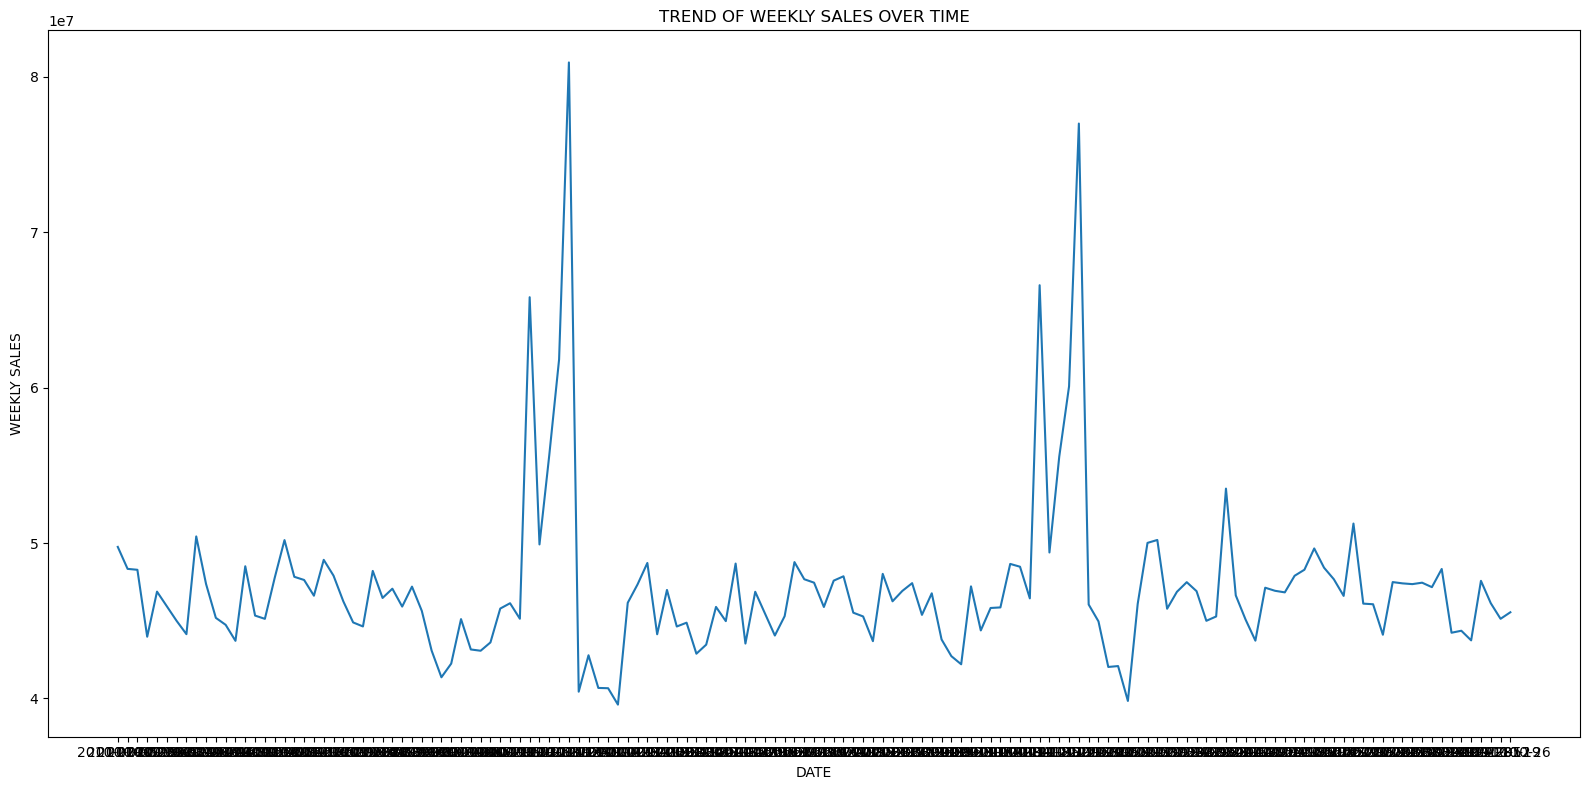

In [12]:
plt.figure(figsize=(16,8))
plt.plot(df_grouped['Date'],df_grouped['Weekly_Sales'])
plt.xlabel('DATE')
plt.ylabel('WEEKLY SALES')
plt.title('TREND OF WEEKLY SALES OVER TIME')
plt.tight_layout()
plt.show();

#### ROLLING-MEAN

In [14]:
df_grouped['rolling_mean_4']=df_grouped['Weekly_Sales'].rolling(4).mean()
df_grouped['rolling_mean_8']=df_grouped['Weekly_Sales'].rolling(8).mean()
df_grouped['rolling_mean_12']=df_grouped['Weekly_Sales'].rolling(12).mean()


In [15]:
df_grouped.head()

,Date,Weekly_Sales,IsHoliday,rolling_mean_4,rolling_mean_8,rolling_mean_12
0,2010-02-05,49750740.50,0,NaN,NaN,NaN
1,2010-02-12,48336677.63,1,NaN,NaN,NaN
2,2010-02-19,48276993.78,0,NaN,NaN,NaN
3,2010-02-26,43968571.13,0,47583245.76,NaN,NaN
4,2010-03-05,46871470.30,0,46863428.21,NaN,NaN


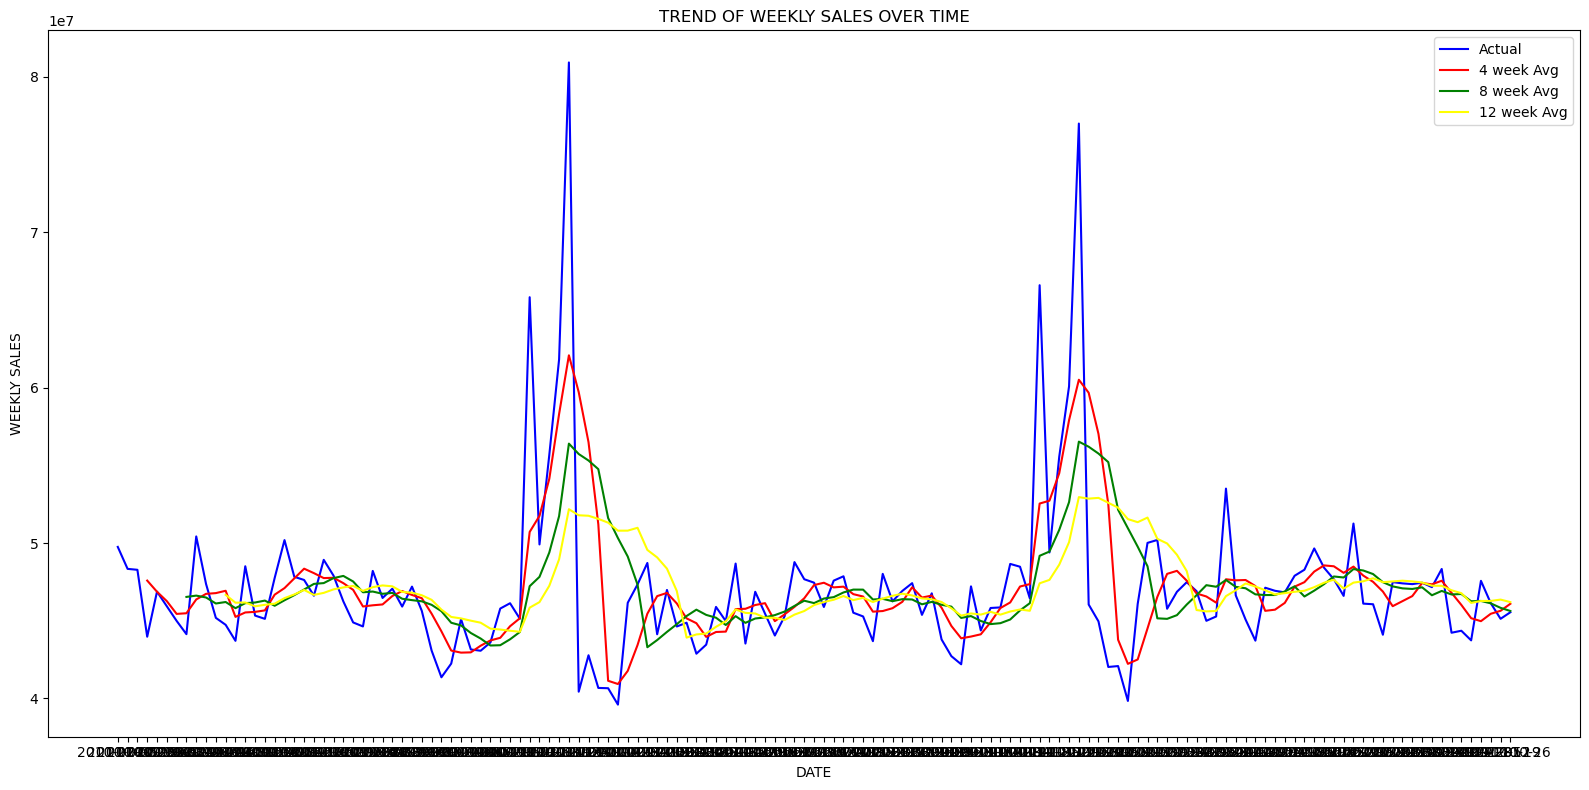

In [16]:
plt.figure(figsize=(16,8))
plt.plot(df_grouped['Date'],df_grouped['Weekly_Sales'],label='Actual',color='blue')
plt.plot(df_grouped['Date'],df_grouped['rolling_mean_4'],label='4 week Avg',color='red')
plt.plot(df_grouped['Date'],df_grouped['rolling_mean_8'],label='8 week Avg',color='green')
plt.plot(df_grouped['Date'],df_grouped['rolling_mean_12'],label='12 week Avg',color='yellow')
plt.xlabel('DATE')
plt.ylabel('WEEKLY SALES')
plt.title('TREND OF WEEKLY SALES OVER TIME')
plt.tight_layout()
plt.legend()
plt.show();

In [17]:
df_grouped['Date']=pd.to_datetime(df_grouped['Date'])

In [18]:
df_grouped['month']=df_grouped['Date'].dt.month

In [19]:
df_grouped.head()

,Date,Weekly_Sales,IsHoliday,rolling_mean_4,rolling_mean_8,rolling_mean_12,month
0,2010-02-05,49750740.50,0,NaN,NaN,NaN,2
1,2010-02-12,48336677.63,1,NaN,NaN,NaN,2
2,2010-02-19,48276993.78,0,NaN,NaN,NaN,2
3,2010-02-26,43968571.13,0,47583245.76,NaN,NaN,2
4,2010-03-05,46871470.30,0,46863428.21,NaN,NaN,3


#### AVG MONTHLY SALES

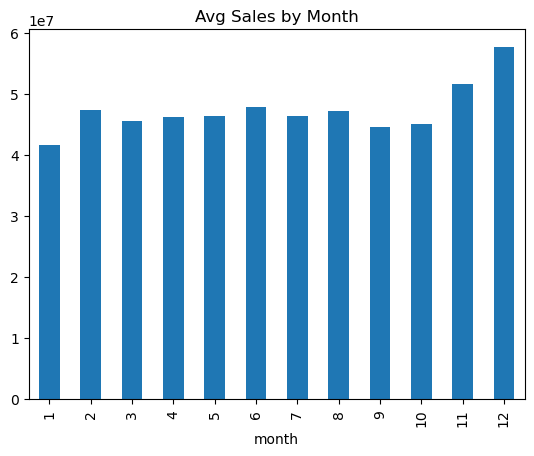

In [21]:
df_grouped.groupby('month')['Weekly_Sales'].mean().plot(kind='bar')
plt.title('Avg Sales by Month')
plt.show();

In [22]:
df_grouped['year']=df_grouped['Date'].dt.year

In [23]:
df_grouped.head()

,Date,Weekly_Sales,IsHoliday,rolling_mean_4,rolling_mean_8,rolling_mean_12,month,year
0,2010-02-05,49750740.50,0,NaN,NaN,NaN,2,2010
1,2010-02-12,48336677.63,1,NaN,NaN,NaN,2,2010
2,2010-02-19,48276993.78,0,NaN,NaN,NaN,2,2010
3,2010-02-26,43968571.13,0,47583245.76,NaN,NaN,2,2010
4,2010-03-05,46871470.30,0,46863428.21,NaN,NaN,3,2010


#### AVG YEARLY SALES

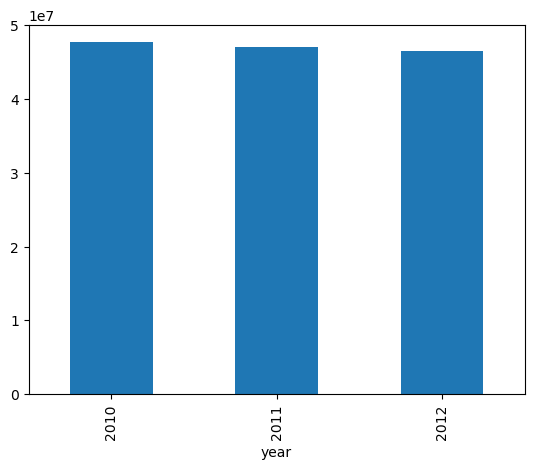

In [25]:
df_grouped.groupby('year')['Weekly_Sales'].mean().plot(kind='bar')
plt.show();

In [26]:
df_grouped=df_grouped.sort_values('Date')

##### ADDING LAG FEATURES

In [28]:
df_grouped['lag_1']=df_grouped['Weekly_Sales'].shift(1)

In [29]:
df_grouped['lag_2']=df_grouped['Weekly_Sales'].shift(2)

In [30]:
df_grouped['lag_3']=df_grouped['Weekly_Sales'].shift(3)

In [31]:
df_grouped['lag_4']=df_grouped['Weekly_Sales'].shift(4)

In [32]:
df_grouped['lag_8']=df_grouped['Weekly_Sales'].shift(8)

In [33]:
df_grouped['lag_12']=df_grouped['Weekly_Sales'].shift(12)

In [34]:
df_grouped.head()

,Date,Weekly_Sales,IsHoliday,rolling_mean_4,rolling_mean_8,rolling_mean_12,month,year,lag_1,lag_2,lag_3,lag_4,lag_8,lag_12
0,2010-02-05,49750740.50,0,NaN,NaN,NaN,2,2010,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-02-12,48336677.63,1,NaN,NaN,NaN,2,2010,49750740.50,NaN,NaN,NaN,NaN,NaN
2,2010-02-19,48276993.78,0,NaN,NaN,NaN,2,2010,48336677.63,49750740.50,NaN,NaN,NaN,NaN
3,2010-02-26,43968571.13,0,47583245.76,NaN,NaN,2,2010,48276993.78,48336677.63,49750740.50,NaN,NaN,NaN
4,2010-03-05,46871470.30,0,46863428.21,NaN,NaN,3,2010,43968571.13,48276993.78,48336677.63,49750740.5,NaN,NaN


In [35]:
df_grouped=df_grouped.dropna()

In [36]:
df_grouped.head()

,Date,Weekly_Sales,IsHoliday,rolling_mean_4,rolling_mean_8,rolling_mean_12,month,year,lag_1,lag_2,lag_3,lag_4,lag_8,lag_12
12,2010-04-30,43705126.71,0,4.524713e+07,4.580759e+07,4.615953e+07,4,2010,44734452.56,45183667.08,47365290.44,50423831.26,46871470.30,49750740.50
13,2010-05-07,48503243.52,0,4.553162e+07,4.612982e+07,4.617341e+07,5,2010,43705126.71,44734452.56,45183667.08,47365290.44,45925396.51,48336677.63
14,2010-05-14,45330080.20,0,4.556823e+07,4.617246e+07,4.592784e+07,5,2010,48503243.52,43705126.71,44734452.56,45183667.08,44988974.64,48276993.78
15,2010-05-21,45120108.06,0,4.566464e+07,4.629572e+07,4.602380e+07,5,2010,45330080.20,48503243.52,43705126.71,44734452.56,44133961.05,43968571.13
16,2010-05-28,47757502.56,0,4.667773e+07,4.596243e+07,4.609764e+07,5,2010,45120108.06,45330080.20,48503243.52,43705126.71,50423831.26,46871470.30


In [37]:
df_grouped.columns

Index(['Date', 'Weekly_Sales', 'IsHoliday', 'rolling_mean_4', 'rolling_mean_8',
       'rolling_mean_12', 'month', 'year', 'lag_1', 'lag_2', 'lag_3', 'lag_4',
       'lag_8', 'lag_12'],
      dtype='object')

In [38]:
features=['month', 'year', 'lag_1','lag_2', 'lag_3', 'lag_4','lag_8','lag_12','rolling_mean_4','rolling_mean_8','rolling_mean_12','IsHoliday']

## MODEL TRAINING AND EVALUATIONS

#### TRAINING USING RANDOM FOREST REGRESSOR

In [41]:
from sklearn.ensemble import RandomForestRegressor
train=df_grouped[df_grouped['Date'] < '2012-01-01']
test=df_grouped[df_grouped['Date'] >= '2012-01-01']

In [42]:
X_train=train[features]
y_train=train['Weekly_Sales']

X_test=test[features]
y_test=test['Weekly_Sales']

In [43]:
rf=RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [44]:
pred=rf.predict(X_test)

#### EVALUATION FOR RANDOM FOREST REGRESSOR

In [46]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [47]:
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
print("MEAN ABSOLUTE ERROR:",mae )
print("MEAN SQUARED ERROR:",mse)
      

MEAN ABSOLUTE ERROR: 1712397.0952093033
MEAN SQUARED ERROR: 5953055035736.588


In [48]:
import numpy as np

In [49]:
rms=np.sqrt(mse)

In [50]:
print(" ROOT MEAN SQUARED ERROR:",rms)

 ROOT MEAN SQUARED ERROR: 2439888.3244395815


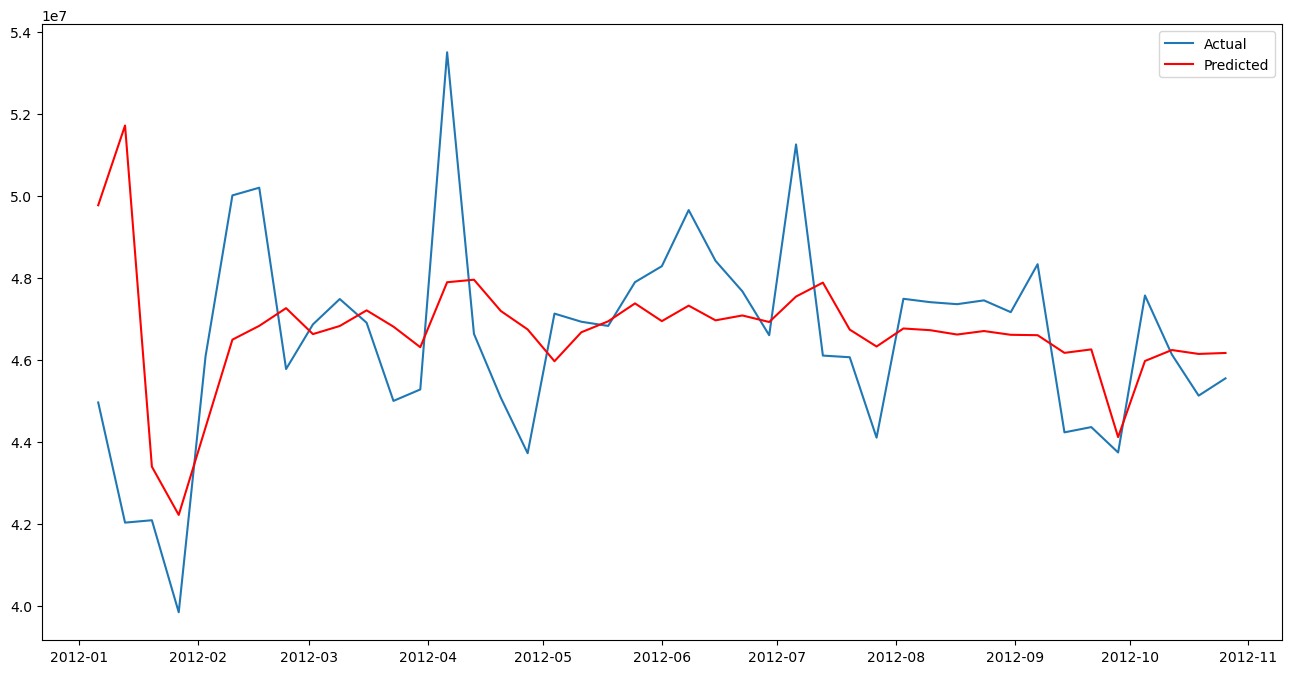

In [51]:
plt.figure(figsize=(16,8))
plt.plot(test['Date'],y_test,label='Actual')
plt.plot(test['Date'],pred,label='Predicted',color='red')
plt.legend()
plt.show();

<!-- ## USING XGBOOST REGRESSOR -->

In [50]:
# from xgboost import XGBRegressor

In [51]:
# X_train_xgb=train[features]
# y_train_xgb=train['Weekly_Sales']

# X_test_xgb=test[features]
# y_test_xgb=test['Weekly_Sales']

In [52]:
# xgb=XGBRegressor()
# xgb.fit(X_train_xgb,y_train_xgb)
# pred_xgb=xgb.predict(X_test_xgb)

In [53]:
# mae_xgb=mean_absolute_error(y_test,pred_xgb)
# mse_xgb=mean_squared_error(y_test,pred_xgb)
# print("MEAN ABSOLUTE ERROR(XGB):",mae_xgb)
# print("MEAN SQUARED ERROR(XGB):",mse_xgb)

MEAN ABSOLUTE ERROR(XGB): 1372251.3174418607
MEAN SQUARED ERROR(XGB): 3530835212994.356


In [54]:
# rms_xgb=np.sqrt(mse_xgb)
# print(" ROOT MEAN SQUARED ERROR(XGB):",rms_xgb)

 ROOT MEAN SQUARED ERROR(XGB): 1879051.6791707342


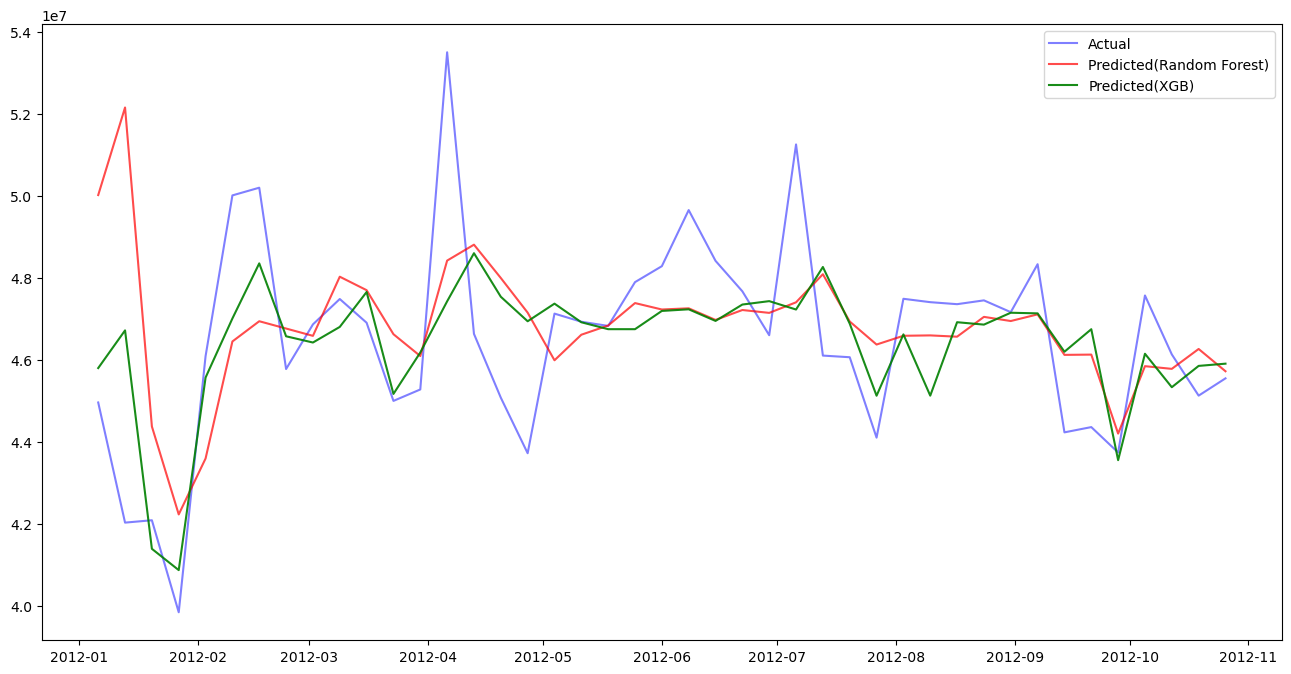

In [55]:
# plt.figure(figsize=(16,8))
# plt.plot(test['Date'],y_test,label='Actual',color='blue',alpha=0.5)
# plt.plot(test['Date'],pred,label='Predicted(Random Forest)',color='red',alpha=0.7)
# plt.plot(test['Date'],pred_xgb,label='Predicted(XGB)',color='green',alpha=0.9)
# plt.legend()
# plt.show();

<!-- ## USING PROPHET MODEL -->

In [57]:
# from prophet import Prophet

In [58]:
# train_prophet=df_grouped[df_grouped['Date']<'2012-01-01'][['Date','Weekly_Sales']]

In [59]:
# train_prophet.head()

,Date,Weekly_Sales
12,2010-04-30,43705126.71
13,2010-05-07,48503243.52
14,2010-05-14,45330080.20
15,2010-05-21,45120108.06
16,2010-05-28,47757502.56


In [60]:
# train_prophet.columns=['ds','y']

In [61]:
# train_prophet.head()

,ds,y
12,2010-04-30,43705126.71
13,2010-05-07,48503243.52
14,2010-05-14,45330080.20
15,2010-05-21,45120108.06
16,2010-05-28,47757502.56


In [62]:
# prophet=Prophet()

In [63]:
# prophet.fit(train_prophet)

18:37:53 - cmdstanpy - INFO - Chain [1] start processing
18:37:55 - cmdstanpy - INFO - Chain [1] done processing


In [64]:
# test_prophet = df_grouped[df_grouped['Date'] >= '2012-01-01'][['Date','Weekly_Sales']]
# test_prophet.columns = ['ds','y']
# forecast=prophet.predict(test_prophet[['ds']])

In [65]:
# mae_prophet =mean_absolute_error(test_prophet['y'], forecast['yhat'])
# mse_prophet= mean_squared_error(test_prophet['y'], forecast['yhat'])
# print("MEAN ABSOLUTE ERROR(Prophet):",mae_prophet)
# print("MEAN SQUARED ERROR(Prophet):",mse_prophet)
# rms_prophet=np.sqrt(mse_prophet)
# print(" ROOT MEAN SQUARED ERROR(Prophet):",rms_prophet)

MEAN ABSOLUTE ERROR(Prophet): 4035621.949968801
MEAN SQUARED ERROR(Prophet): 20349475325565.297
 ROOT MEAN SQUARED ERROR(Prophet): 4511039.273334394


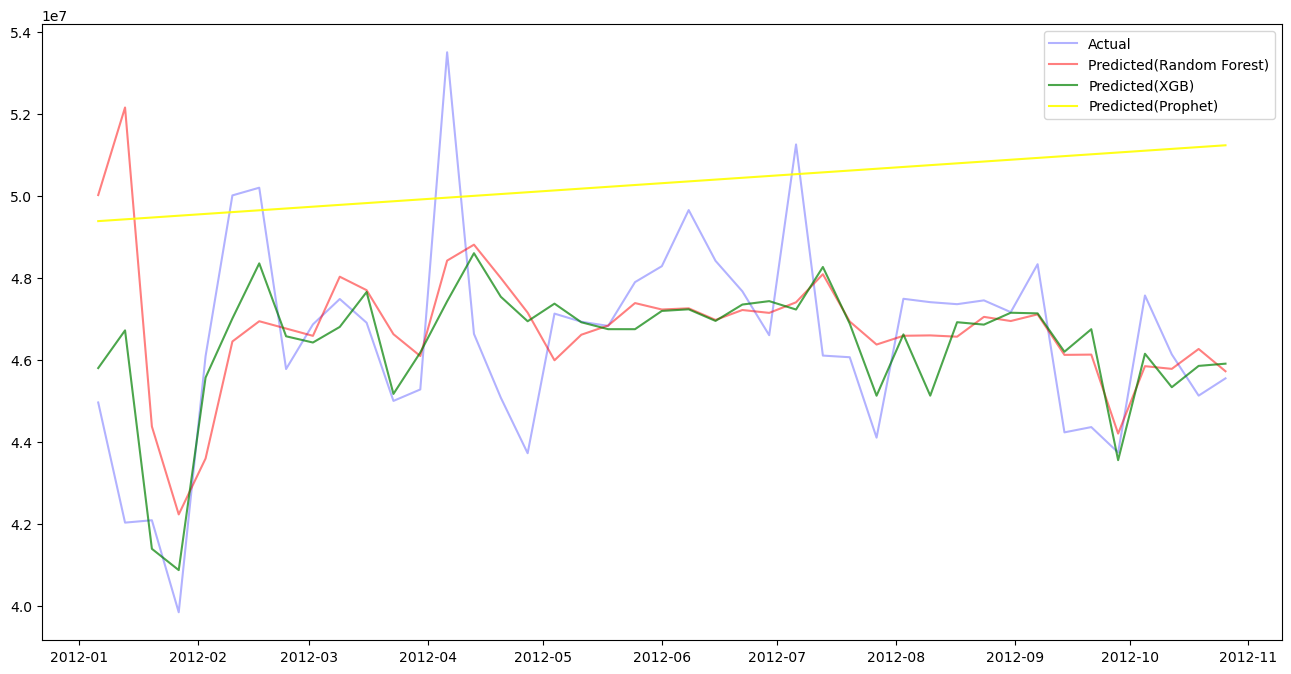

In [66]:
# plt.figure(figsize=(16,8))
# plt.plot(test['Date'],y_test,label='Actual',color='blue',alpha=0.3)
# plt.plot(test['Date'],pred,label='Predicted(Random Forest)',color='red',alpha=0.5)
# plt.plot(test['Date'],pred_xgb,label='Predicted(XGB)',color='green',alpha=0.7)
# plt.plot(test['Date'],forecast['yhat'],label='Predicted(Prophet)',color='yellow',alpha=0.9)
# plt.legend()
# plt.show();

<!-- ## LIGHTGBM -->

In [68]:
# from lightgbm import LGBMRegressor

In [69]:
# X_train_lgbm=train[features]
# y_train_lgbm=train['Weekly_Sales']

# X_test_lgbm=test[features]
# y_test_lgbm=test['Weekly_Sales']

In [70]:
# lgbm=LGBMRegressor(max_depth=3,min_data_in_leaf=5,n_estimators=100)
# lgbm.fit(X_train_lgbm,y_train_lgbm)
# pred_lgbm=lgbm.predict(X_test_lgbm)

[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001459 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 297
[LightGBM] [Info] Number of data points in the train set: 88, number of used features: 12
[LightGBM] [Info] Start training from score 47467342.136364
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

In [71]:
# mae_lgbm=mean_absolute_error(y_test,pred_lgbm)
# mse_lgbm=mean_squared_error(y_test,pred_lgbm)
# print("MEAN ABSOLUTE ERROR(LGBM):",mae_lgbm)
# print("MEAN SQUARED ERROR(LGBM):",mse_lgbm)
# rms_lgbm=np.sqrt(mse_lgbm)
# print(" ROOT MEAN SQUARED ERROR(LGBM):",rms_lgbm)

MEAN ABSOLUTE ERROR(LGBM): 2010878.795529545
MEAN SQUARED ERROR(LGBM): 7213010257691.676
 ROOT MEAN SQUARED ERROR(LGBM): 2685704.7971978746


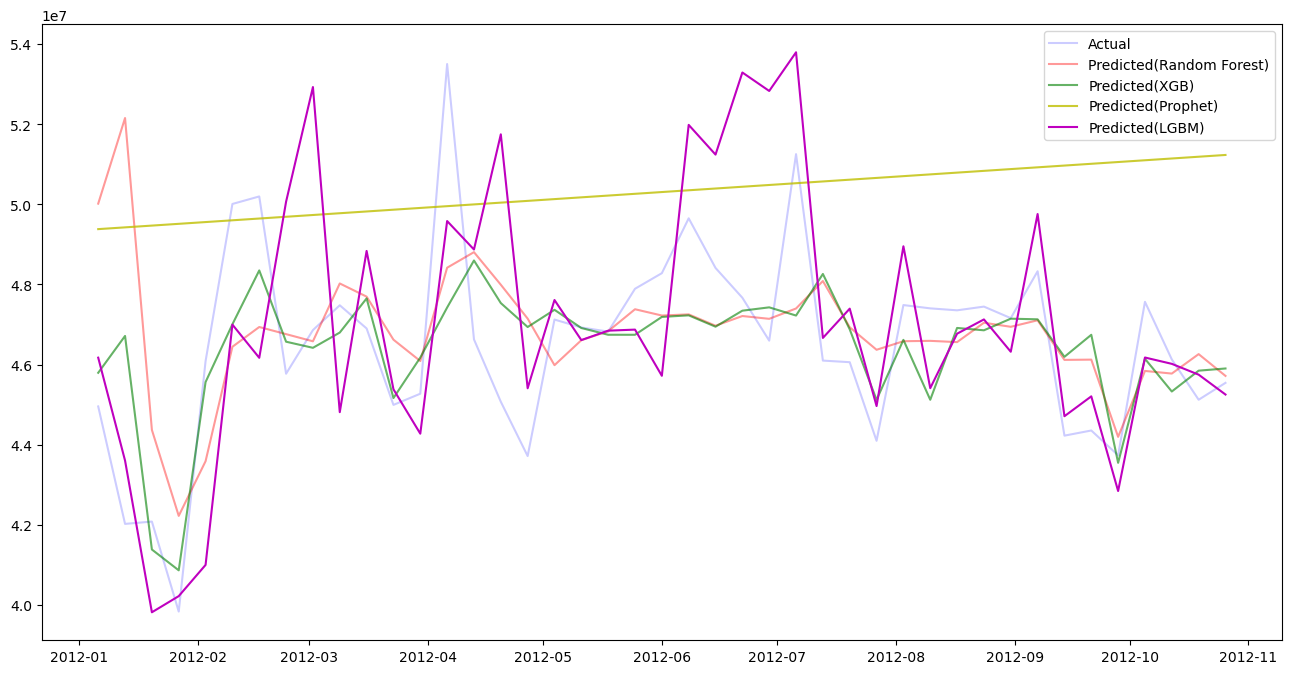

In [72]:
# plt.figure(figsize=(16,8))
# plt.plot(test['Date'],y_test,label='Actual',color='b',alpha=0.2)
# plt.plot(test['Date'],pred,label='Predicted(Random Forest)',color='r',alpha=0.4)
# plt.plot(test['Date'],pred_xgb,label='Predicted(XGB)',color='g',alpha=0.6)
# plt.plot(test['Date'],forecast['yhat'],label='Predicted(Prophet)',color='y',alpha=0.8)
# plt.plot(test['Date'],pred_lgbm,label='Predicted(LGBM)',color='m')
# plt.legend()
# plt.show();